# Chargement des données d’images

Jusqu’à présent, nous avons travaillé avec des ensembles de données assez artificiels, peu représentatifs des projets réels.  
Dans la pratique, vous serez souvent amené à manipuler des **images de grande taille**, comme celles issues d’appareils photo ou de téléphones portables.  
Dans ce notebook, nous verrons comment **charger des images** et les utiliser pour **entraîner des réseaux de neurones**.

Nous utiliserons un [jeu de données de photos de chats et de chiens](https://www.kaggle.com/c/dogs-vs-cats) disponible sur **Kaggle**.  
Voici quelques exemples d’images :



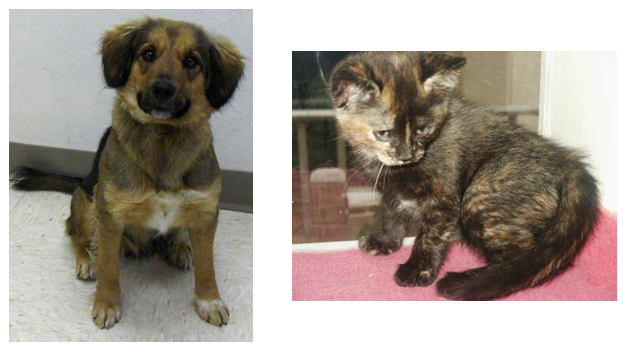

Nous emploierons ce jeu de données pour entraîner un réseau de neurones capable de **distinguer les chats des chiens**.  
Aujourd’hui, cela peut sembler banal, mais il y a encore quelques années, c’était un véritable **défi pour les systèmes de vision par ordinateur**.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import matplotlib.pyplot as plt
import random
import numpy as np

import torch
import torch.nn as nn

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

import helper


La façon la plus simple de charger des images est d’utiliser `datasets.ImageFolder` de la bibliothèque **torchvision** ([documentation](http://pytorch.org/docs/master/torchvision/datasets.html#imagefolder)).  
En général, vous utiliserez `ImageFolder` comme ceci :

```python
dataset = datasets.ImageFolder('path/to/data', transform=transform)
````

où `'path/to/data'` est le chemin d’accès au répertoire contenant les données, et `transform` est une **séquence d’opérations de prétraitement** définies à l’aide du module [`transforms`](http://pytorch.org/docs/master/torchvision/transforms.html) de `torchvision`.

`ImageFolder` s’attend à une structure de répertoires comme celle-ci :

```
root/dog/xxx.png
root/dog/xxy.png
root/dog/xxz.png

root/cat/123.png
root/cat/nsdf3.png
root/cat/asd932_.png
```

Chaque classe (ici `cat` et `dog`) possède son **propre dossier** contenant les images correspondantes.
Les images sont alors automatiquement **étiquetées** d’après le nom du dossier.
Ainsi, l’image `123.png` sera chargée avec l’étiquette `cat`.

Vous pouvez télécharger le jeu de données déjà structuré de cette manière [ici](https://s3.amazonaws.com/content.udacity-data.com/nd089/Cat_Dog_data.zip).
Il est déjà séparé en **jeu d’entraînement** et **jeu de test**.

---

### 🔄 Transformations

Lors du chargement des données avec `ImageFolder`, il faut définir des **transformations (transforms)**.
Par exemple, les images ont des tailles différentes, mais le modèle nécessite qu’elles aient toutes la même taille pour l’entraînement.
On peut donc :

* les **redimensionner** avec `transforms.Resize()`, ou
* les **rogner** avec `transforms.CenterCrop()` ou `transforms.RandomResizedCrop()`.

Il faut également **convertir les images en tenseurs PyTorch** à l’aide de `transforms.ToTensor()`.

En général, ces étapes sont combinées en un pipeline à l’aide de `transforms.Compose()`, qui exécute une liste de transformations dans l’ordre.
Par exemple, pour redimensionner, recadrer, puis convertir en tenseur :

```python
transform = transforms.Compose([
    transforms.Resize(255),
    transforms.CenterCrop(224),
    transforms.ToTensor()
])
```

Il existe de nombreuses autres transformations possibles — consultez la [documentation](http://pytorch.org/docs/master/torchvision/transforms.html) pour plus de détails.

---

### 📦 Data Loaders

Une fois le `ImageFolder` chargé, il faut le passer à un [`DataLoader`](http://pytorch.org/docs/master/data.html#torch.utils.data.DataLoader).
Le **DataLoader** prend un dataset (par exemple celui renvoyé par `ImageFolder`) et retourne des **lots (batches)** d’images et leurs **étiquettes** correspondantes.
Vous pouvez régler plusieurs paramètres, comme :

* la **taille des lots (`batch_size`)**,
* et le **mélange des données (`shuffle`)** à chaque époque.

Exemple :

```python
dataloader = torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=True)
```

L’objet `dataloader` est un **générateur**.
Pour extraire des données, on peut soit boucler dessus, soit le convertir en itérateur et appeler `next()` :

```python
# Boucle pour récupérer un batch à chaque itération
for images, labels in dataloader:
    pass

# Obtenir un seul batch
images, labels = next(iter(dataloader))
```

---

> **Exercice :**
> Chargez les images depuis le dossier `Cat_Dog_data/train`,
> définissez quelques transformations,
> puis construisez le **DataLoader**.



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# setting working Directory
import os
os.chdir('/content/drive/MyDrive/Deep learning Master IA/cnn_cat_dog_image_classification-20260521T190648Z-3-001/cnn_cat_dog_image_classification')

In [4]:
#Seed + GPU
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(42)

#Test pour CUDA
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
%ls

 adam_model.pth
 best_cnn_model.pth
 best_model_adam.pth
 best_model_resnet18_adam.pth
 best_model_sgd.pth
 Cat_Dog_data/
'Copie de Part 7 - Loading Image Data (exo)_v2.ipynb'
'Copie Vrai de Part 7 - Loading Image Data (exo)_v2.ipynb'
 __MACOSX/
 my_helper.py
'Part 7 - Loading Image Data (exo)_v2.ipynb'
 resnet18_model.pth
 sgd_model.pth


In [ ]:
# extract Cat_Dog_data.zip
#!unzip Cat_Dog_data.zip

In [6]:
#Prétraitement des données
from torch.utils.data import DataLoader
data_dir = 'Cat_Dog_data/train'

transform = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )])# TODO: compose transforms here
dataset = datasets.ImageFolder(
    data_dir,
    transform=transform)# TODO: create the ImageFolder
dataloader = torch.utils.data.DataLoader(
    dataset,
    batch_size= 16,
    shuffle=True,
    num_workers= 2)# TODO: use the ImageFolder dataset to create the DataLoader

In [7]:
#Visualisation des images
import matplotlib.pyplot as plt
import numpy as np
import torch

def imshow(image, ax=None, title=None, normalize=True):
    """Imshow for Tensor."""
    if ax is None:
        fig, ax = plt.subplots()
    image = image.numpy().transpose((1, 2, 0))
    if normalize:
        mean = np.array([0.485, 0.456, 0.406])
        std = np.array([0.229, 0.224, 0.225])
        image = std * image + mean
        image = np.clip(image, 0, 1)

    ax.imshow(image)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.tick_params(axis='both', length=0)
    ax.set_xticklabels('')
    ax.set_yticklabels('')

    return ax

<Axes: >

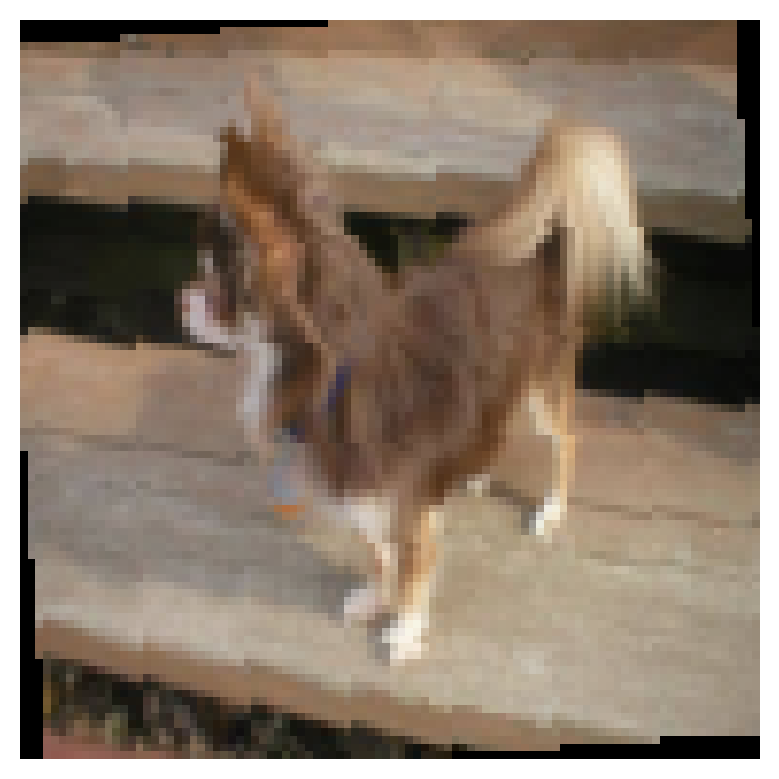

In [8]:
# Run this to test your data loader
images, labels = next(iter(dataloader))
imshow(images[0])

Si vous avez correctement chargé les données, vous devriez obtenir un affichage similaire à celui-ci (votre image sera différente) :




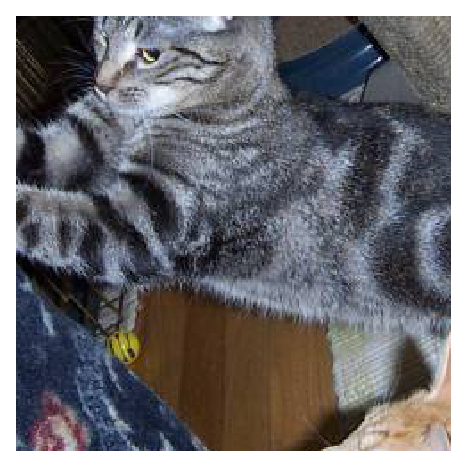


## Augmentation de Données

Une stratégie courante pour entraîner des réseaux de neurones consiste à introduire une **certaine forme d’aléatoire dans les données d’entrée**.  
Par exemple, on peut faire tourner, refléter, redimensionner et/ou rogner aléatoirement les images pendant l’entraînement.  
Cela aide le réseau à **mieux généraliser**, car il voit les mêmes images sous différentes formes : positions, tailles, orientations, etc.

Pour appliquer une rotation, un recadrage et un redimensionnement aléatoires, puis retourner les images horizontalement, on peut définir les transformations ainsi :

```python
train_transforms = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])
````

Il est également recommandé de **normaliser les images** à l’aide de `transforms.Normalize`.
Cette transformation prend en entrée :

* une liste de **moyennes** (`mean`)
* et une liste d’**écarts-types** (`std`)

Chaque canal de couleur est alors normalisé selon la formule :

```
input[channel] = (input[channel] - mean[channel]) / std[channel]
```

Soustraire la moyenne recentre les données autour de zéro,
et diviser par l’écart-type comprime les valeurs entre **-1 et 1**.
Cette normalisation aide à maintenir les **poids du réseau proches de zéro**,
rendant ainsi la **rétropropagation plus stable**.
Sans normalisation, le réseau risque souvent d’échouer à apprendre correctement.

Vous pouvez consulter la **liste complète des transformations disponibles** [ici](http://pytorch.org/docs/0.3.0/torchvision/transforms.html).

Lors des phases de **validation** ou de **test**, on utilise généralement des images **non altérées** (hormis la normalisation).
Ainsi, pour les données de validation ou de test, on se contente en général de **redimensionner** et **recadrer** les images.

---

> **Exercice :**
> Définissez ci-dessous les **transformations** pour les données d’entraînement et de test.
> Ne mettez pas encore la normalisation.

```



In [9]:
data_dir = 'Cat_Dog_data'

# TODO: Define transforms for the training data and testing data
train_transforms = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])

test_transforms = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])])


# Pass transforms in here, then run the next cell to see how the transforms look
train_data = datasets.ImageFolder(data_dir + '/train', transform=train_transforms)
test_data = datasets.ImageFolder(data_dir + '/test', transform=test_transforms)

#Reduire le dataset
#from torch.utils.data import Subset
#small_train_data = Subset(train_data, range(1000))
#small_test_data = Subset(test_data, range(700))

#Suite normal
trainloader = torch.utils.data.DataLoader(train_data, batch_size=16, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(test_data, batch_size=16, shuffle=False, num_workers=2)

In [10]:
# change this to the trainloader or testloader
data_iter = iter(trainloader)

In [11]:
images, labels = next(data_iter)
labels


tensor([1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1])

In [12]:
print(train_data.class_to_idx)

{'cat': 0, 'dog': 1}


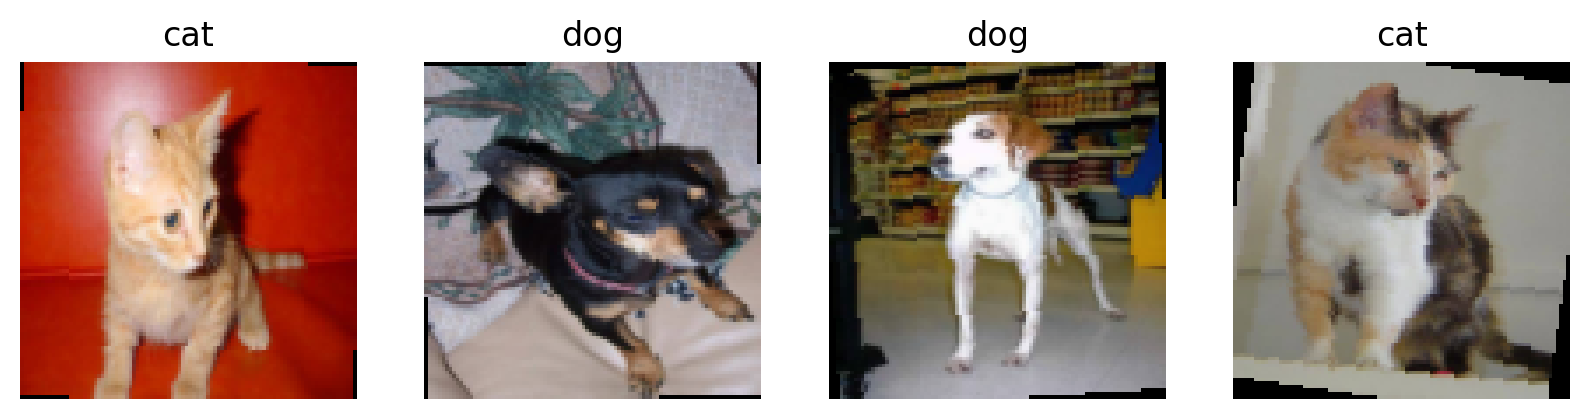

In [13]:

images, labels = next(data_iter)
fig, axes = plt.subplots(figsize=(10,4), ncols=4)
classes = ['cat', 'dog']
for ii in range(4):
    ax = axes[ii]
    imshow(images[ii], ax=ax)
    ax.set_title(classes[labels[ii]])

Vos images transformées devraient ressembler à quelque chose comme ceci.




<center>Training examples:</center>


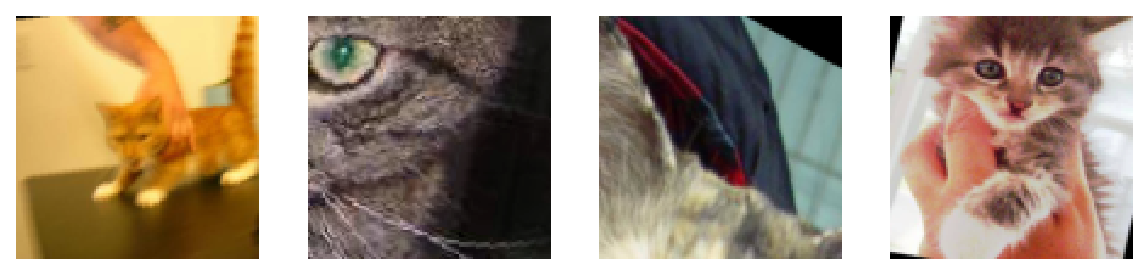

<center>Testing examples:</center>

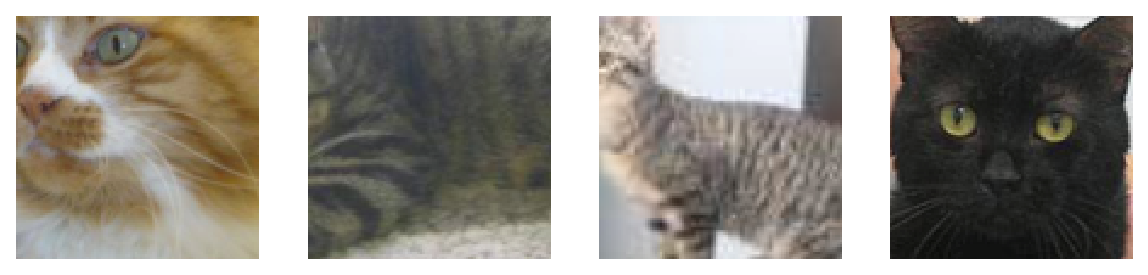


À ce stade, vous devriez être en mesure de charger les données pour l’entraînement et le test.  
Vous pouvez maintenant essayer de construire un réseau capable de **classer les chats et les chiens**.



In [14]:
#  TODO: Attempt to build a network with CNN to classify cats vs dogs from this dataset
# --- créer un model from scratc
import torch.nn as nn
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            # Bloc 1
            nn.Conv2d(
                in_channels=3,
                out_channels=16,
                kernel_size=3,
                padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Bloc 2
            nn.Conv2d(
                in_channels=16,
                out_channels=32,
                kernel_size=3,
                padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            # Bloc 3
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25))

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 12 * 12, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2))

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [15]:
#Créer le modèle
model = CatDogCNN()

model.to(device)

CatDogCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.25, inplace=False)
    (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatte

In [16]:
#Fonction d'évaluation du modèle
def evaluate_model(model, dataloader, criterion):
    model.eval()
    y_true = []
    y_pred = []
    running_loss = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            y_true.extend(labels.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    avg_loss = running_loss / len(dataloader)

    return avg_loss, accuracy, precision, recall

In [17]:
#Fonction d'entrainement complete du modèle
def train_model(model, optimizer, optimizer_name, epochs=5):
    criterion = nn.CrossEntropyLoss()
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer,
        step_size=3,
        gamma=0.1)

    train_losses = []
    test_losses = []

    train_accuracies = []
    test_accuracies = []

    best_accuracy = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        y_true_train = []
        y_pred_train = []

        for images, labels in trainloader:
            images = images.to(device)
            labels = labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            y_true_train.extend(labels.cpu().numpy())
            y_pred_train.extend(preds.cpu().numpy())

        scheduler.step()

        train_loss = running_loss / len(trainloader)
        train_acc = accuracy_score(
            y_true_train,
            y_pred_train)

        test_loss, test_acc, precision, recall = evaluate_model(
            model,
            testloader,
            criterion)

        train_losses.append(train_loss)
        test_losses.append(test_loss)

        train_accuracies.append(train_acc)
        test_accuracies.append(test_acc)

        print(f"\nOptimizer: {optimizer_name}")
        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Train Accuracy: {train_acc:.4f}")
        print(f"Test Loss: {test_loss:.4f}")
        print(f"Test Accuracy: {test_acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")

        if test_acc > best_accuracy:
            best_accuracy = test_acc
            torch.save(
                model.state_dict(),
                f"best_model_{optimizer_name}.pth")

    history = {
        "train_losses": train_losses,
        "test_losses": test_losses,
        "train_accuracies": train_accuracies,
        "test_accuracies": test_accuracies}
    return history

In [18]:
#Expérience Adam
model_adam = CatDogCNN().to(device)

optimizer_adam = torch.optim.Adam(
    model_adam.parameters(),
    lr=0.001,
    weight_decay=1e-4)

history_adam = train_model(
    model_adam,
    optimizer_adam,
    optimizer_name="adam",
    epochs=10)


Optimizer: adam
Epoch 1/10
Train Loss: 0.6693
Train Accuracy: 0.5912
Test Loss: 0.6115
Test Accuracy: 0.6756
Precision: 0.7654
Recall: 0.5064

Optimizer: adam
Epoch 2/10
Train Loss: 0.5989
Train Accuracy: 0.6672
Test Loss: 0.5738
Test Accuracy: 0.7004
Precision: 0.8371
Recall: 0.4976

Optimizer: adam
Epoch 3/10
Train Loss: 0.5600
Train Accuracy: 0.6969
Test Loss: 0.5180
Test Accuracy: 0.7360
Precision: 0.8495
Recall: 0.5736

Optimizer: adam
Epoch 4/10
Train Loss: 0.5165
Train Accuracy: 0.7288
Test Loss: 0.4789
Test Accuracy: 0.7688
Precision: 0.8200
Recall: 0.6888

Optimizer: adam
Epoch 5/10
Train Loss: 0.5028
Train Accuracy: 0.7486
Test Loss: 0.4782
Test Accuracy: 0.7668
Precision: 0.8286
Recall: 0.6728

Optimizer: adam
Epoch 6/10
Train Loss: 0.4931
Train Accuracy: 0.7563
Test Loss: 0.4646
Test Accuracy: 0.7724
Precision: 0.8227
Recall: 0.6944

Optimizer: adam
Epoch 7/10
Train Loss: 0.4837
Train Accuracy: 0.7607
Test Loss: 0.4661
Test Accuracy: 0.7720
Precision: 0.8414
Recall: 0.6704

In [19]:
#Expérience SGD
model_sgd = CatDogCNN().to(device)

optimizer_sgd = torch.optim.SGD(
    model_sgd.parameters(),
    lr=0.01,
    momentum=0.9)

history_sgd = train_model(
    model_sgd,
    optimizer_sgd,
    optimizer_name="sgd",
    epochs=10)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Optimizer: sgd
Epoch 1/10
Train Loss: 0.7006
Train Accuracy: 0.4952
Test Loss: 0.6935
Test Accuracy: 0.5000
Precision: 0.0000
Recall: 0.0000

Optimizer: sgd
Epoch 2/10
Train Loss: 0.6939
Train Accuracy: 0.5016
Test Loss: 0.6934
Test Accuracy: 0.5000
Precision: 0.0000
Recall: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Optimizer: sgd
Epoch 3/10
Train Loss: 0.6938
Train Accuracy: 0.5016
Test Loss: 0.6936
Test Accuracy: 0.5000
Precision: 0.5000
Recall: 1.0000

Optimizer: sgd
Epoch 4/10
Train Loss: 0.6932
Train Accuracy: 0.5065
Test Loss: 0.6934
Test Accuracy: 0.5000
Precision: 0.0000
Recall: 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Optimizer: sgd
Epoch 5/10
Train Loss: 0.6932
Train Accuracy: 0.5037
Test Loss: 0.6931
Test Accuracy: 0.5000
Precision: 0.5000
Recall: 1.0000

Optimizer: sgd
Epoch 6/10
Train Loss: 0.6932
Train Accuracy: 0.5035
Test Loss: 0.6932
Test Accuracy: 0.4996
Precision: 0.0000
Recall: 0.0000

Optimizer: sgd
Epoch 7/10
Train Loss: 0.6932
Train Accuracy: 0.5000
Test Loss: 0.6932
Test Accuracy: 0.4996
Precision: 0.4000
Recall: 0.0016

Optimizer: sgd
Epoch 8/10
Train Loss: 0.6932
Train Accuracy: 0.4956
Test Loss: 0.6932
Test Accuracy: 0.5004
Precision: 0.5556
Recall: 0.0040

Optimizer: sgd
Epoch 9/10
Train Loss: 0.6932
Train Accuracy: 0.4962
Test Loss: 0.6932
Test Accuracy: 0.5000
Precision: 0.5000
Recall: 0.0064

Optimizer: sgd
Epoch 10/10
Train Loss: 0.6932
Train Accuracy: 0.5000
Test Loss: 0.6932
Test Accuracy: 0.5004
Precision: 0.5333
Recall: 0.0064


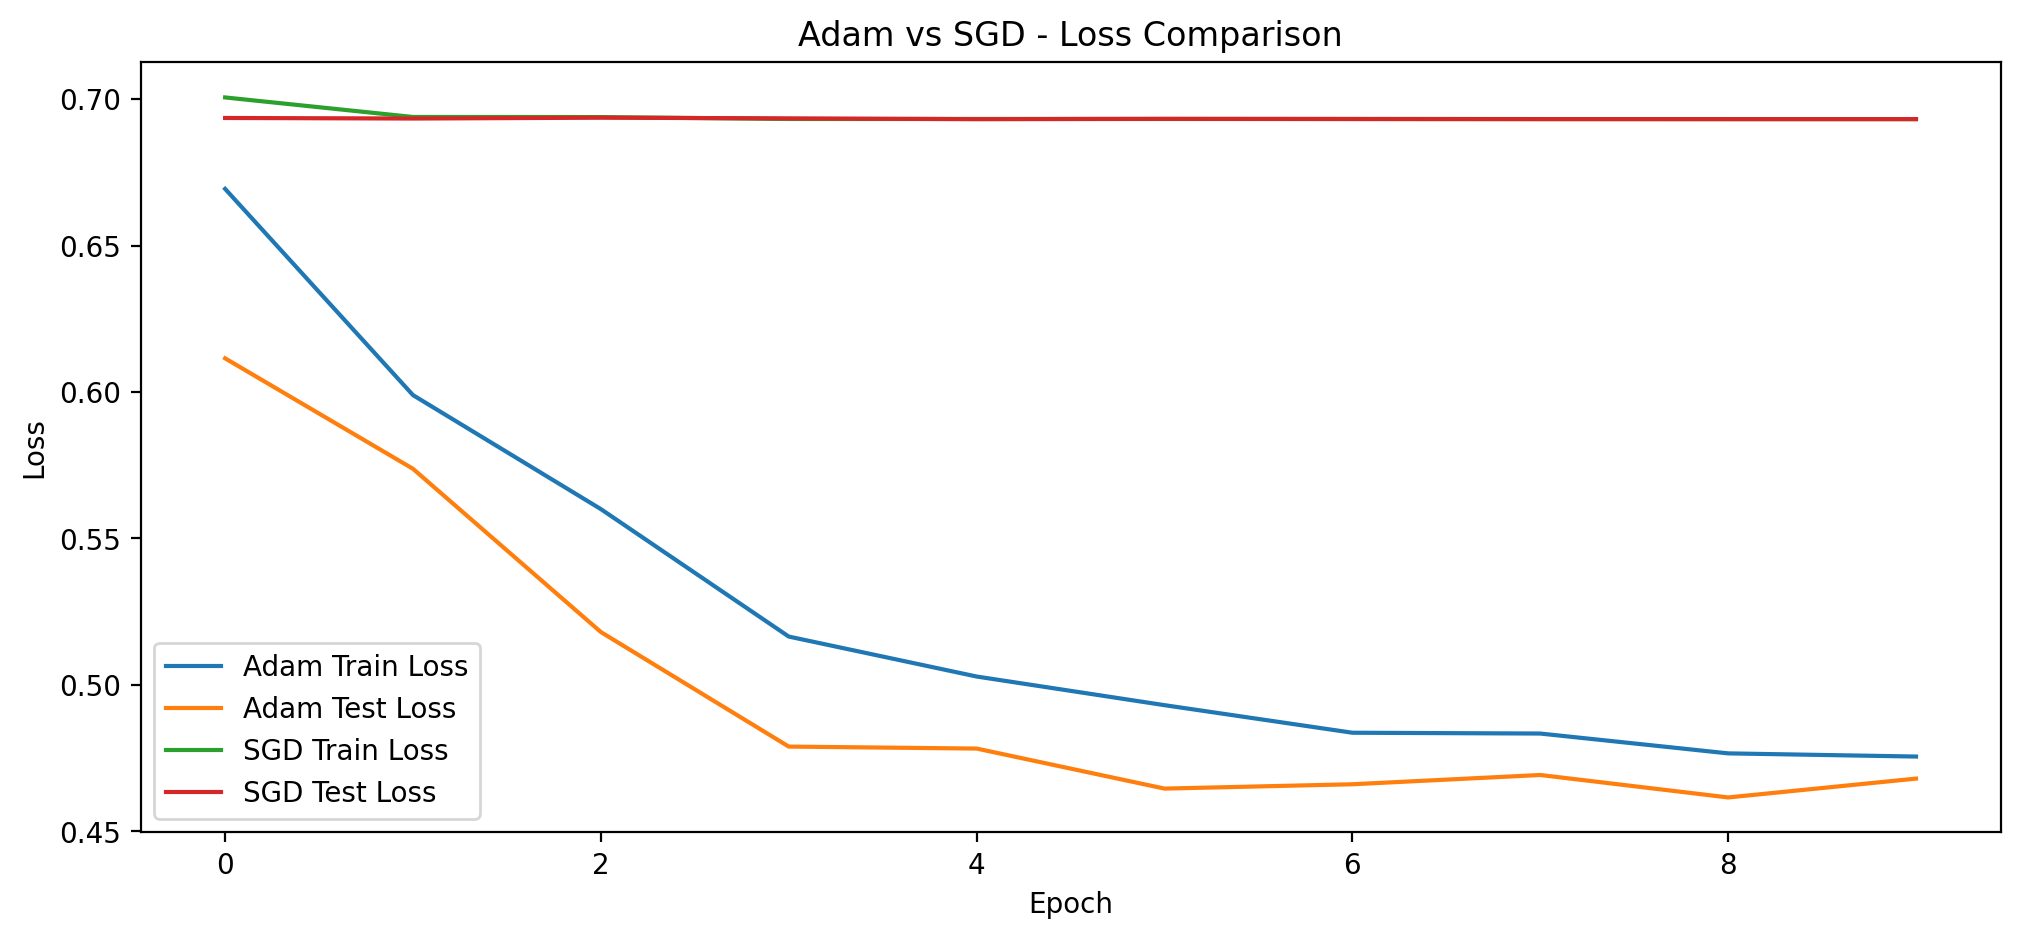

In [20]:
#Graphe LOSS COMPARATIF
plt.figure(figsize=(12,5))
plt.plot(
    history_adam["train_losses"],
    label="Adam Train Loss")

plt.plot(
    history_adam["test_losses"],
    label="Adam Test Loss")

plt.plot(
    history_sgd["train_losses"],
    label="SGD Train Loss")

plt.plot(
    history_sgd["test_losses"],
    label="SGD Test Loss")

plt.legend()
plt.title("Adam vs SGD - Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

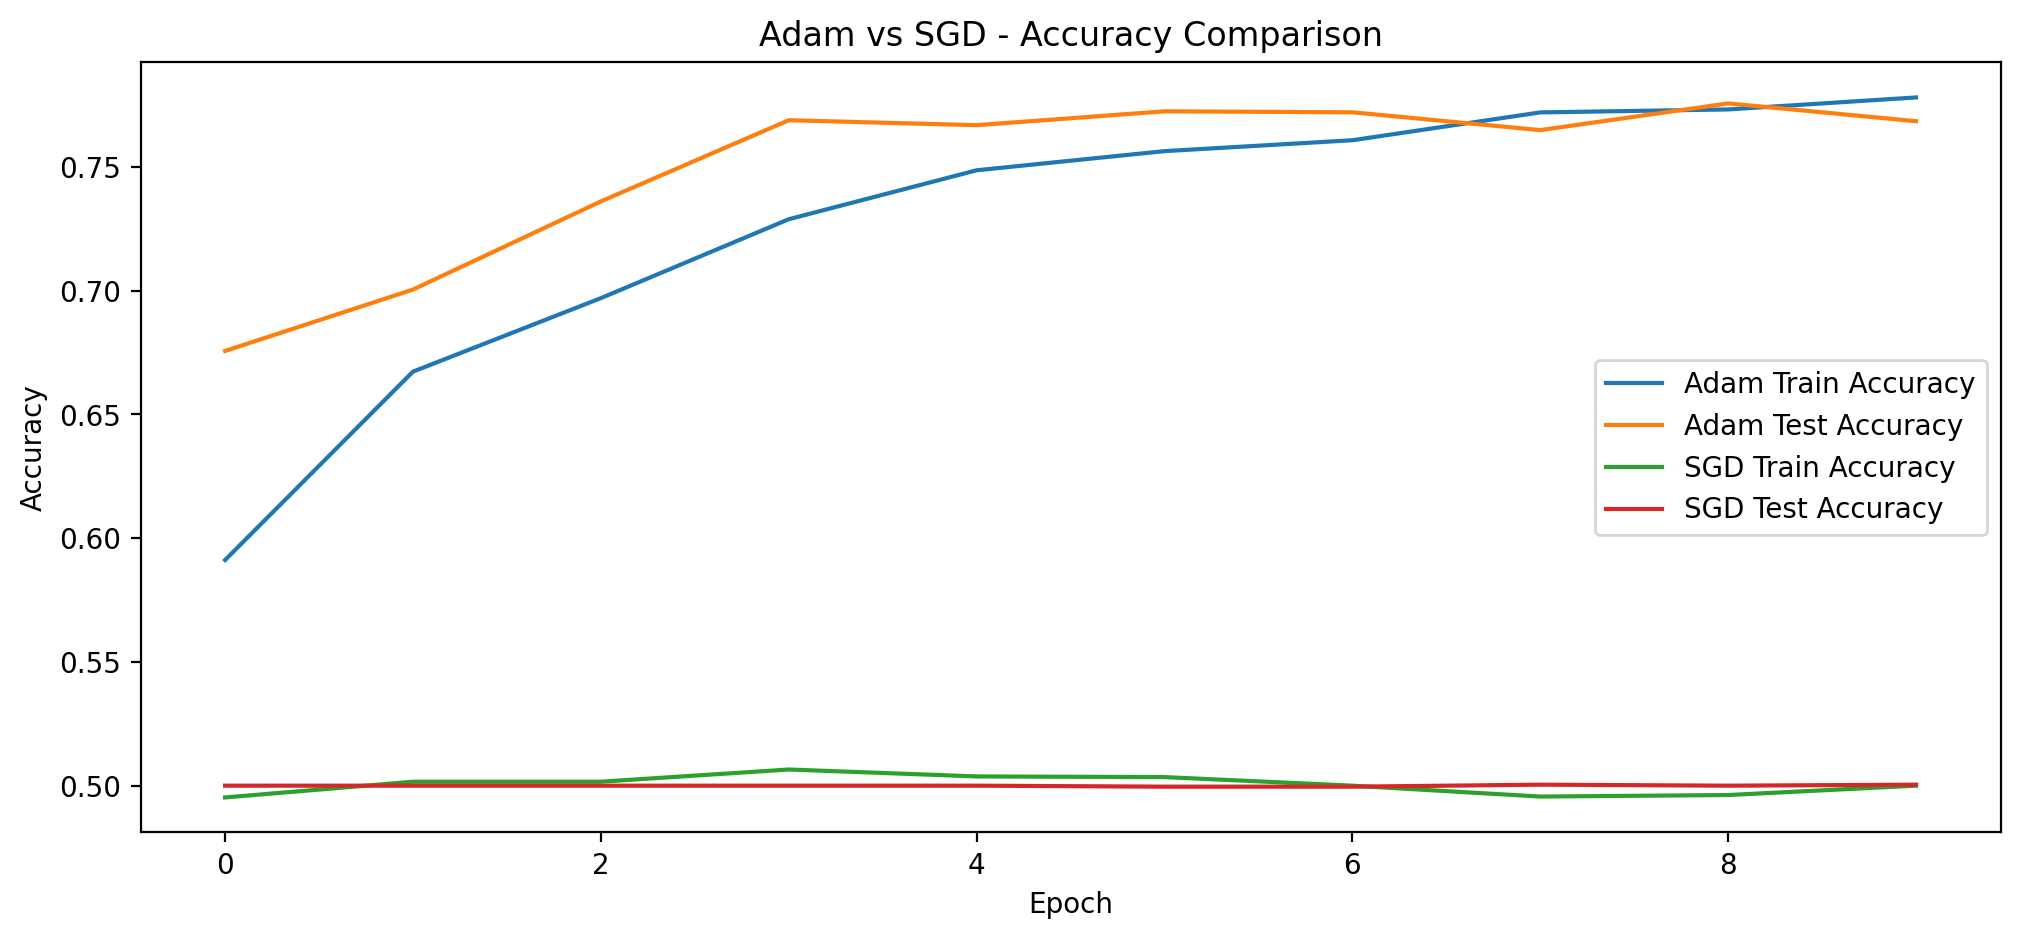

In [21]:
#Graphe ACCURACY COMPARATIF
plt.figure(figsize=(12,5))
plt.plot(
    history_adam["train_accuracies"],
    label="Adam Train Accuracy")

plt.plot(
    history_adam["test_accuracies"],
    label="Adam Test Accuracy")

plt.plot(
    history_sgd["train_accuracies"],
    label="SGD Train Accuracy")

plt.plot(
    history_sgd["test_accuracies"],
    label="SGD Test Accuracy")

plt.legend()
plt.title("Adam vs SGD - Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

In [22]:
#Recharger le meilleur modèle Adam
best_model_adam = CatDogCNN().to(device)
best_model_adam.load_state_dict(torch.load("best_model_adam.pth"))
best_model_adam.eval()

CatDogCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.25, inplace=False)
    (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatte

In [23]:
#Recharger le meilleur modèle SGD
best_model_sgd = CatDogCNN().to(device)
best_model_sgd.load_state_dict(torch.load("best_model_sgd.pth"))
best_model_sgd.eval()

CatDogCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
    (5): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.25, inplace=False)
    (10): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.25, inplace=False)
  )
  (classifier): Sequential(
    (0): Flatte

In [24]:
#Évaluation finale Adam et SGD
criterion = nn.CrossEntropyLoss()
#Adam
adam_test_loss, adam_test_acc, adam_precision, adam_recall = evaluate_model(
    best_model_adam,
    testloader,
    criterion)

print("=== Adam Final Results ===")
print(f"Test Loss: {adam_test_loss:.4f}")
print(f"Test Accuracy: {adam_test_acc:.4f}")
print(f"Precision: {adam_precision:.4f}")
print(f"Recall: {adam_recall:.4f}")

#SGD
sgd_test_loss, sgd_test_acc, sgd_precision, sgd_recall = evaluate_model(
    best_model_sgd,
    testloader,
    criterion)

print("=== SGD Final Results ===")
print(f"Test Loss: {sgd_test_loss:.4f}")
print(f"Test Accuracy: {sgd_test_acc:.4f}")
print(f"Precision: {sgd_precision:.4f}")
print(f"Recall: {sgd_recall:.4f}")

=== Adam Final Results ===
Test Loss: 0.4616
Test Accuracy: 0.7756
Precision: 0.8368
Recall: 0.6848
=== SGD Final Results ===
Test Loss: 0.6932
Test Accuracy: 0.5004
Precision: 0.5556
Recall: 0.0040


Les expérimentations ont montré que l’optimiseur Adam converge plus rapidement et atteint de meilleures performances que SGD sur notre architecture CNN entraînée from scratch. SGD semble avoir eu des difficultés à converger dans le nombre limité d’époques utilisées sur CPU.

**Expérience B — Transfer Learning**

In [25]:
#Charger ResNet18 pré_entrainé
from torchvision import models
model_transfer = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 110MB/s]


In [26]:
#Geler les couches convolutionnelles
for param in model_transfer.parameters():
    param.requires_grad = False

In [27]:
#Remplacer la dernière couche
model_transfer.fc = nn.Sequential(
    nn.Linear(model_transfer.fc.in_features,128),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(128, 2))

In [28]:
#Envoyer sur device
model_transfer = model_transfer.to(device)

In [29]:
#Loss et optimizer: On utilise Adam car : il a gagné la comparaison précédente
criterion_transfer = nn.CrossEntropyLoss()

optimizer_transfer = torch.optim.Adam(
    model_transfer.fc.parameters(),
    lr=0.001)
#Scheduler
scheduler_transfer = torch.optim.lr_scheduler.StepLR(
    optimizer_transfer,
    step_size=3,
    gamma=0.1)

In [31]:
#Entrainement du modèle avec ResNet18
#Comme on a déjà une fonction générique en haut, on l'utilise ici :
history_transfer = train_model(
    model_transfer,
    optimizer_transfer,
    optimizer_name="resnet18_adam",
    epochs=10)


Optimizer: resnet18_adam
Epoch 1/10
Train Loss: 0.3634
Train Accuracy: 0.8323
Test Loss: 0.3029
Test Accuracy: 0.8660
Precision: 0.9024
Recall: 0.8208

Optimizer: resnet18_adam
Epoch 2/10
Train Loss: 0.3578
Train Accuracy: 0.8353
Test Loss: 0.3027
Test Accuracy: 0.8704
Precision: 0.9054
Recall: 0.8272

Optimizer: resnet18_adam
Epoch 3/10
Train Loss: 0.3635
Train Accuracy: 0.8333
Test Loss: 0.3016
Test Accuracy: 0.8680
Precision: 0.8692
Recall: 0.8664

Optimizer: resnet18_adam
Epoch 4/10
Train Loss: 0.3606
Train Accuracy: 0.8338
Test Loss: 0.3079
Test Accuracy: 0.8588
Precision: 0.8540
Recall: 0.8656

Optimizer: resnet18_adam
Epoch 5/10
Train Loss: 0.3569
Train Accuracy: 0.8340
Test Loss: 0.2957
Test Accuracy: 0.8756
Precision: 0.8671
Recall: 0.8872

Optimizer: resnet18_adam
Epoch 6/10
Train Loss: 0.3618
Train Accuracy: 0.8341
Test Loss: 0.2972
Test Accuracy: 0.8692
Precision: 0.8830
Recall: 0.8512

Optimizer: resnet18_adam
Epoch 7/10
Train Loss: 0.3568
Train Accuracy: 0.8371
Test Loss

In [35]:
#Recharger le meilleur modèle
best_transfer_model = models.resnet18(pretrained=False)

In [36]:
best_transfer_model.fc = nn.Sequential(

    nn.Linear(
        best_transfer_model.fc.in_features,
        128),

    nn.ReLU(),

    nn.Dropout(0.5),

    nn.Linear(128, 2))

In [37]:
best_transfer_model.load_state_dict(
    torch.load("best_model_resnet18_adam.pth"))
best_transfer_model = best_transfer_model.to(device)
best_transfer_model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [38]:
#Évaluation finale
criterion = nn.CrossEntropyLoss()
transfer_test_loss, transfer_test_acc, transfer_precision, transfer_recall = evaluate_model(
    best_transfer_model,
    testloader,
    criterion
)

print("=== ResNet18 Transfer Learning Results ===")
print(f"Test Loss: {transfer_test_loss:.4f}")
print(f"Test Accuracy: {transfer_test_acc:.4f}")
print(f"Precision: {transfer_precision:.4f}")
print(f"Recall: {transfer_recall:.4f}")

=== ResNet18 Transfer Learning Results ===
Test Loss: 0.2957
Test Accuracy: 0.8756
Precision: 0.8671
Recall: 0.8872


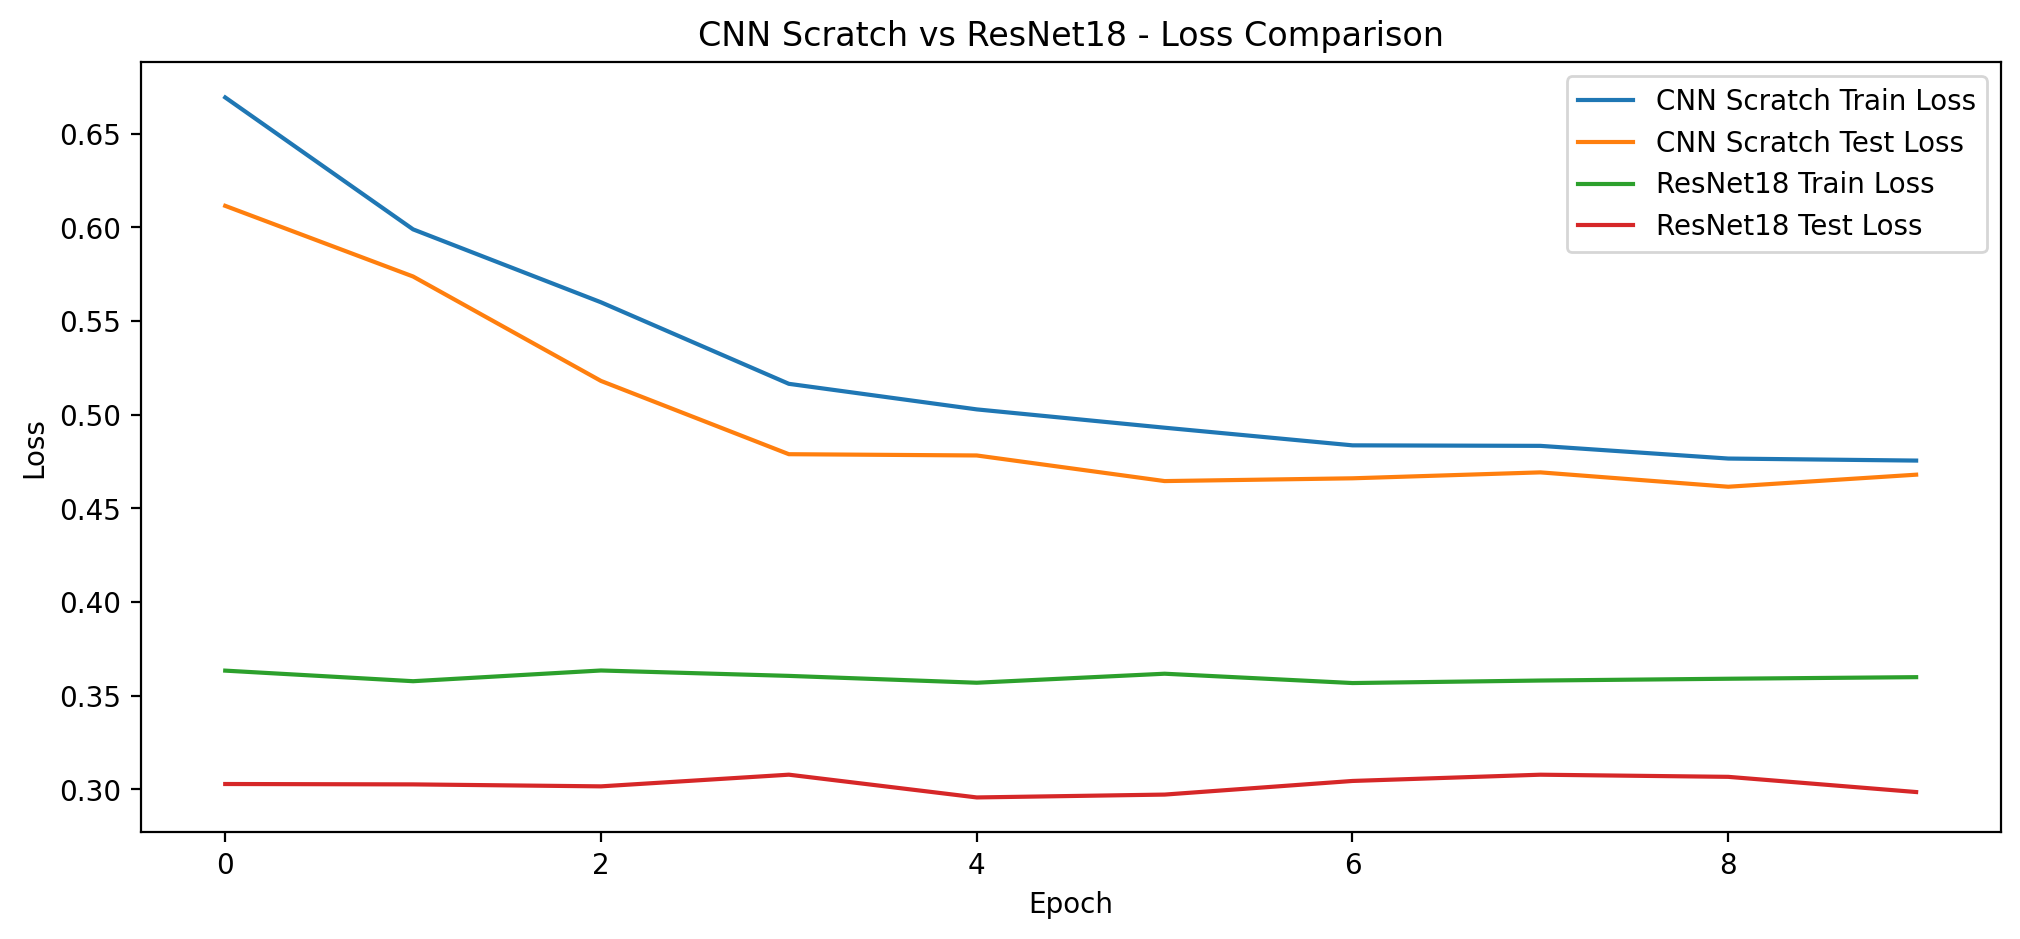

In [39]:
#Graphe LOSS COMPARISON
plt.figure(figsize=(12,5))

# CNN Scratch
plt.plot(
    history_adam["train_losses"],
    label="CNN Scratch Train Loss")

plt.plot(
    history_adam["test_losses"],
    label="CNN Scratch Test Loss")

# ResNet18
plt.plot(
    history_transfer["train_losses"],
    label="ResNet18 Train Loss")

plt.plot(
    history_transfer["test_losses"],
    label="ResNet18 Test Loss")

plt.title("CNN Scratch vs ResNet18 - Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

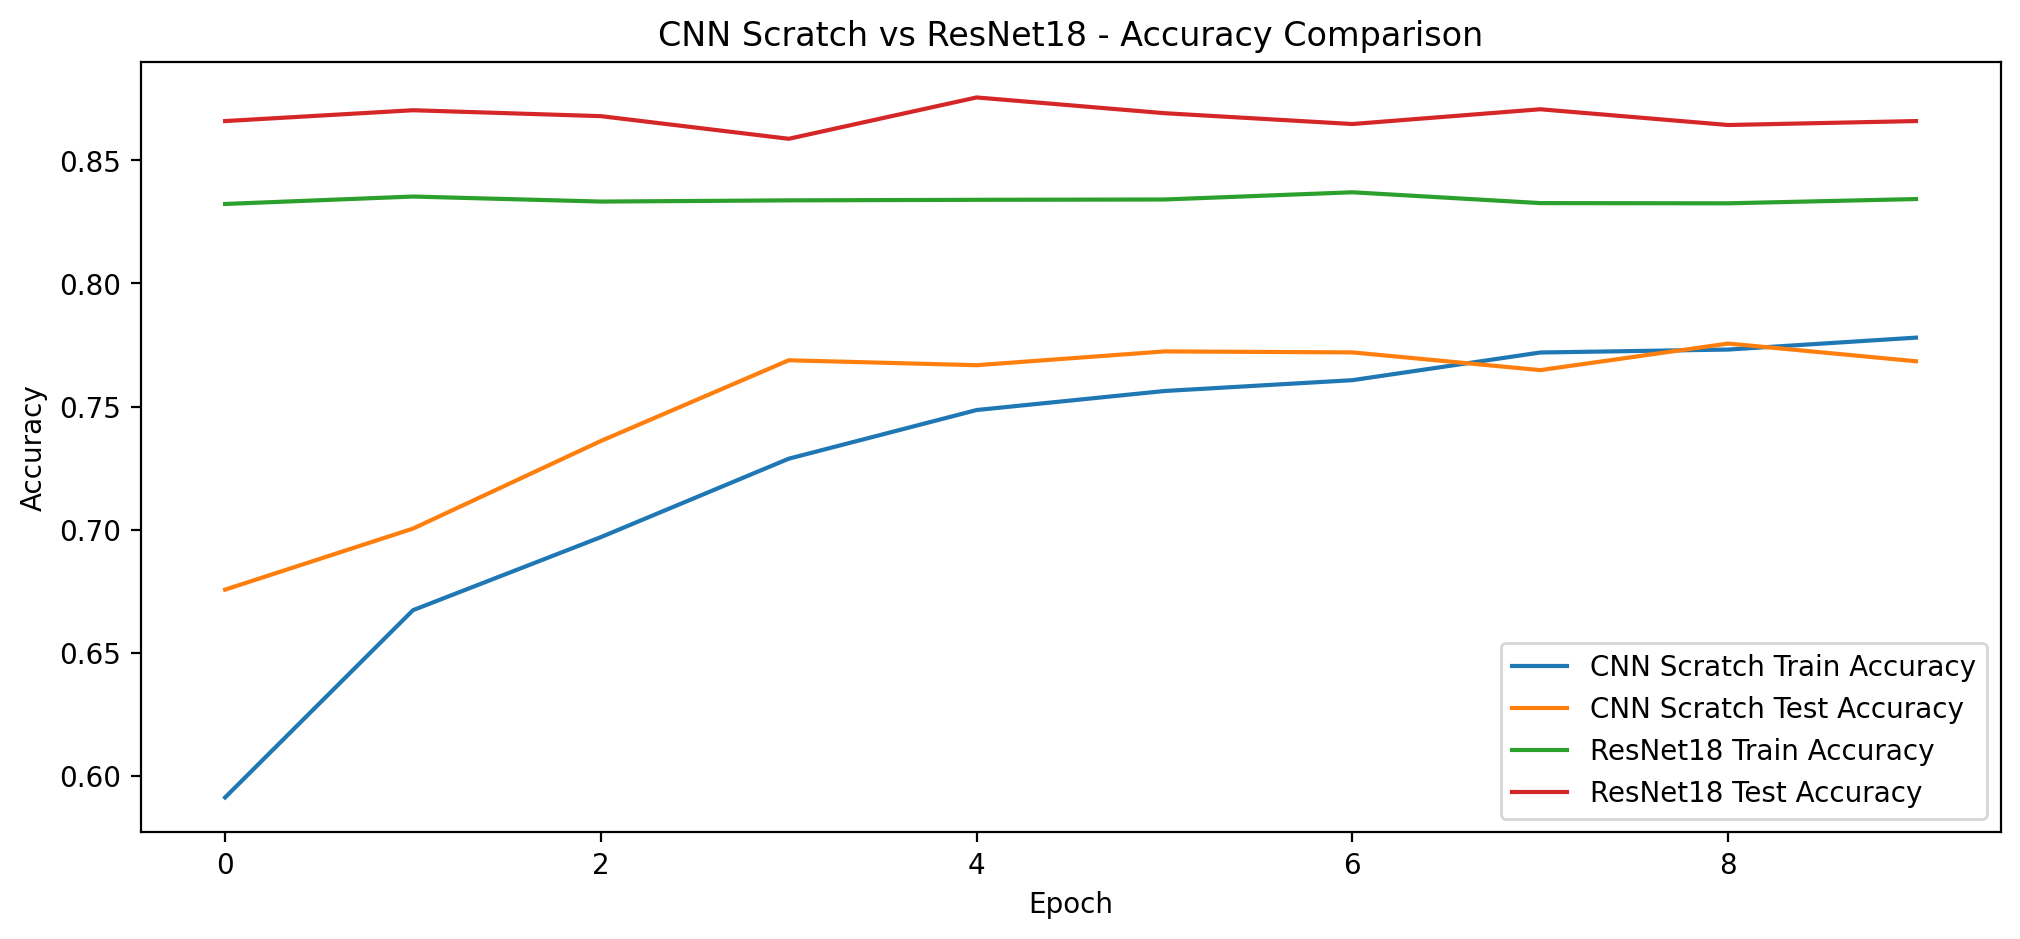

In [40]:
#Graphe ACCURACY COMPARISON
plt.figure(figsize=(12,5))

# CNN Scratch
plt.plot(
    history_adam["train_accuracies"],
    label="CNN Scratch Train Accuracy")

plt.plot(
    history_adam["test_accuracies"],
    label="CNN Scratch Test Accuracy")

# ResNet18
plt.plot(
    history_transfer["train_accuracies"],
    label="ResNet18 Train Accuracy")

plt.plot(
    history_transfer["test_accuracies"],
    label="ResNet18 Test Accuracy")

plt.title("CNN Scratch vs ResNet18 - Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [41]:
#Comparaison finale des métriques
print("===== FINAL MODEL COMPARISON =====")

print("\n--- CNN Scratch (Adam) ---")
print(f"Loss      : {adam_test_loss:.4f}")
print(f"Accuracy  : {adam_test_acc:.4f}")
print(f"Precision : {adam_precision:.4f}")
print(f"Recall    : {adam_recall:.4f}")

print("\n--- ResNet18 Transfer Learning ---")
print(f"Loss      : {transfer_test_loss:.4f}")
print(f"Accuracy  : {transfer_test_acc:.4f}")
print(f"Precision : {transfer_precision:.4f}")
print(f"Recall    : {transfer_recall:.4f}")

===== FINAL MODEL COMPARISON =====

--- CNN Scratch (Adam) ---
Loss      : 0.4616
Accuracy  : 0.7756
Precision : 0.8368
Recall    : 0.6848

--- ResNet18 Transfer Learning ---
Loss      : 0.2957
Accuracy  : 0.8756
Precision : 0.8671
Recall    : 0.8872


Analyse des résultats
Comparaison CNN from scratch vs Transfer Learning

Le modèle ResNet18 pré-entraîné a montré une convergence plus rapide et de meilleures performances globales que le CNN entraîné from scratch.

Le transfer learning permet de réutiliser des représentations visuelles déjà apprises sur ImageNet, ce qui améliore :

la vitesse d’apprentissage,
la robustesse,
et la généralisation.

Le CNN from scratch nécessite davantage de données et d’époques pour atteindre des performances comparables.

Comparaison Adam vs SGD

Adam a montré une convergence plus rapide et plus stable que SGD dans notre expérience. SGD semble avoir eu des difficultés à converger correctement avec le nombre limité d’époques utilisé sur CPU.

Adam a donc été retenu pour l’expérience de transfer learning.

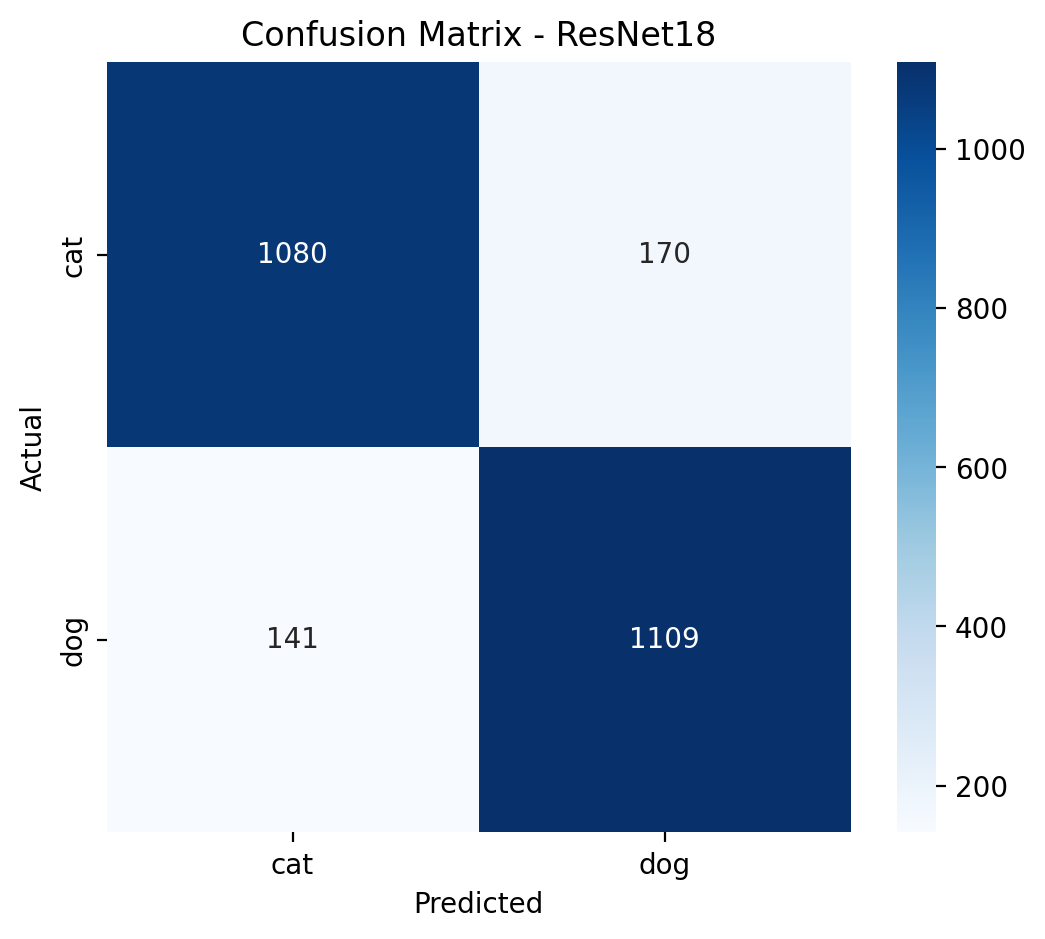

In [42]:
#Matrice de confusion
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_true = []
y_pred = []

best_transfer_model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = best_transfer_model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["cat","dog"],
    yticklabels=["cat","dog"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet18")
plt.show()


La matrice de confusion du modele ResNet8 montre une bonne capacité de discrimination entre les classes "chat" et chien. Sur un total de 2500 images de test, 2189 ont été correctement classées, ce qui correspond à une exaltitude  de 87,76%. Les erreurs de classification restent limitées avec 170 chats confondus avec des chiens et 141 chiens confondus avec des chats. Les valeurs de précision et de rappel superieurs à 86% pour les deux classes confirment la robustesse du modèle et sa bonne capacité de généralisation.

In [43]:
#Quelques erreurs typiques commentées
misclassified = []
best_transfer_model.eval()
with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        outputs = best_transfer_model(images)
        _, preds = torch.max(outputs, 1)
        for img, pred, label in zip(
            images.cpu(),
            preds.cpu(),
            labels):
            if pred != label:
                misclassified.append(
                    (img, pred.item(), label.item()))

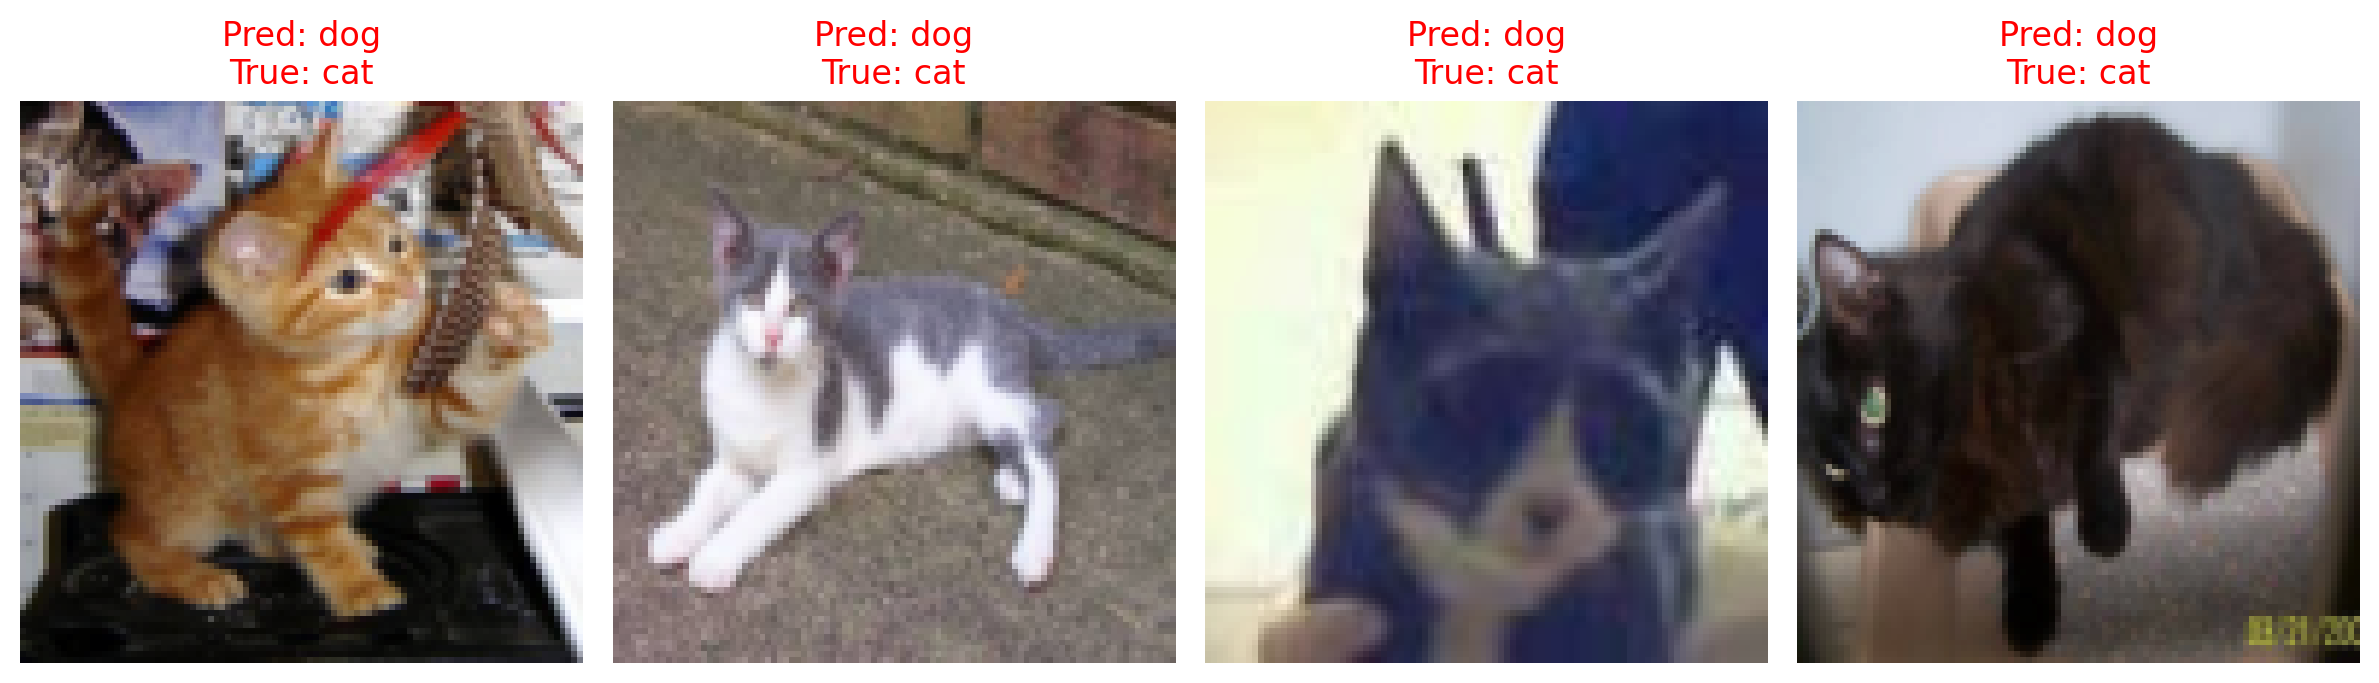

In [51]:
#Affichage des 4 premieres erreurs
fig, axes = plt.subplots(1, 4, figsize=(12,4))
classes = ['cat', 'dog']
for i in range(min(4, len(misclassified))):
    img, pred, true = misclassified[i]
    ax = axes[i]
    imshow(img, ax=ax)
    ax.set_title(
        f"Pred: {classes[pred]}\nTrue: {classes[true]}",
        color="red")
plt.tight_layout()
plt.show()

Analyse des erreurs :

Les images présentées correspondent à des exemples d'erreurs de classification réalisées par ResNet18. Dans ces cas, des chats ont été incorrectement identifiés comme des chiens. Ces erreurs sont principalement dues à des similitudes visuelles entre les deux classes ou à des conditions d'acquisition difficiles (flou, faible contraste, posture inhabituelle).
Malgré ces quelques confusions, le modèle ResNet18 obtient de bonnes performances globales grâce au transfert d'apprentissage.

# TP – CNN “from scratch” vs Transfert Learning (Cats vs Dogs)

## Objectif

Comparer **un modèle CNN entraîné from scratch** et **un modèle en transfert d’apprentissage** sur le même jeu de données (cats vs dogs). Montrer l’impact du transfert learning sur la convergence, la performance et la robustesse.

## Ce qui est **obligatoire**

1. **Deux expériences distinctes**

   * Expérience A : CNN **from scratch** (architecture simple minimum 3 bloc avec conv).
   * Expérience B : **Transfert learning** (ex. ResNet, MobileNet, EfficientNet…), couches finales adaptées.
2. **Bonnes pratiques de régularisation**

   * Utiliser **Dropout** ET **Batch Normalization** (justifier où et pourquoi).
3. **Suivi des métriques**

   * **Training loss**, **Accuracy**, **Précision**, **Recall** à chaque époque (et idéalement sur train/val si vous faites une validation).
   * Tracer des **courbes** et **comparer** les deux approches.
4. **Optimisation**

   * Tester au moins **2 optimiseurs** (ex. SGD et Adam).
   * Chercher un **bon learning rate** (essais ou scheduler).
5. **GPU**

   * Entraîner **sur GPU** si disponible (vérification et mention dans README).
6. **Persistance du modèle**

   * **Sauvegarder** le meilleur modèle (.pt/.pth) localement (ne **pas** pousser dans GitHub).
   * **Recharger** le modèle pour faire le **test final** et rapporter les métriques.
7. **Reproductibilité**

   * Fixer un **seed**

## Ce qui est **souhaité (bonus)**

* **Split train/validation** (clair et justifié).
* **Data augmentation** raisonnable.
* **Scheduler** (ex. StepLR, CosineAnnealingLR).
* **Matrice de confusion** et quelques **erreurs typiques** commentées.
* Journalisation (TensorBoard/W&B) — sans pousser les fichiers lourds.

## Données

* Utilisez le même corpus **Cats vs Dogs** que vu en cours (ou équivalent).
* Ne **poussez pas** les données sur GitHub. Indiquez seulement **comment** les télécharger/placer.

## Structure du dépôt GitHub (exemple)

```
cnn-catsdogs-<NomPrenom>/
├─ notebook.ipynb
├─ .gitignore
├─ requirements.txt (ou environment.yml)
├─ README.md
└─ LICENSE (optionnel)
```

### `.gitignore` (minimum)

```
data/
*.pt
*.pth
runs/
checkpoints/
```

## Contenu attendu du **README.md**

* **Titre & objectif** du projet.
* **Environnement** ( `pip install -r requirements.txt` ou `conda env create -f environment.yml`).
* **Organisation des données** (où télécharger, où placer les dossiers).
* **Commandes pour entraîner** :

  * From scratch : arguments clés (batch size, lr, epochs, optimiser, dropout, BN, scheduler…).
  * Transfert learning : même chose + quelle base (gel des couches ou fine-tuning).
* **Commandes pour évaluer / recharger le modèle** (chemin du checkpoint local).
* **Résultats** : tableaux + courbes (loss/accuracy/précision/recall) pour les deux expériences, **comparaison et analyse** (2–3 paragraphes).
* **Limites & pistes d’amélioration** (brèves).

## Évaluation (grille indicative)

* Rigueur expérimentale & métriques (30 %)
* Qualité des modèles & optimisation (25 %)
* Clarté du code & structure du dépôt (20 %)
* README (reproductibilité, analyse, figures) (20 %)
* Bonus (val split, augmentation, scheduler, confusion matrix) (5 %)

## Remise

* **Poussez votre code sur GitHub** (sans données ni modèles).
* Envoyez **le lien du dépôt** à **[diallomous@gmail.com](mailto:diallomous@gmail.com)**
* **Date limite : jeud  04/juin/2026 avant 23h00. (Africa/Dakar).**

> Rappel : ne chargez pas les fichiers lourds (datasets, `.pt/.pth`). Assurez-vous que votre dépôt permet de **reproduire** les expériences via les instructions du README.
